# CIFAR-10 Object Recognition using ResNet50

This project uses deep learning and transfer learning with ResNet50 to classify images from the CIFAR-10 dataset.

## Objective

The objective is to build an image classification model that can recognize 10 object categories from CIFAR-10 images.

In [4]:
!pip install kaggle

In [5]:
#configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# dataset api
!kaggle competitions download -c cifar-10

100% 715M/715M [00:19<00:00, 38.9MB/s]



In [7]:
!ls

cifar-10.zip  kaggle.json  sample_data


In [8]:
# extracting the compressed dataset
from zipfile import ZipFile
datatset = "/content/cifar-10.zip"

with ZipFile(datatset,"r") as zip:
  zip.extractall()
  print("the dataset is extracted")

the dataset is extracted


In [9]:
!ls

cifar-10.zip  sample_data	    test.7z   trainLabels.csv
kaggle.json   sampleSubmission.csv  train.7z


In [10]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.3/494.3 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 17.3 MB/s eta 0:00:00


In [11]:
import py7zr
archive = py7zr.SevenZipFile("/content/train.7z", mode='r')
archive.extractall()
archive.close()

In [12]:
!ls

cifar-10.zip  sample_data	    test.7z  train.7z
kaggle.json   sampleSubmission.csv  train    trainLabels.csv


Importing the dependencies

In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [14]:
filenames = os.listdir("/content/train")

In [15]:
type(filenames)

list

In [16]:
len(filenames)

50000

In [17]:
print(filenames[0:5])
print(filenames[-5:])

['49881.png', '39013.png', '5440.png', '23993.png', '1266.png']
['9538.png', '20191.png', '45852.png', '44910.png', '12695.png']


Labels processing

In [18]:
labels_df = pd.read_csv("/content/trainLabels.csv")

In [19]:
labels_df.shape

(50000, 2)

In [20]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [21]:
labels_df[labels_df["id"]==7796]

,id,label
7795,7796,frog


In [22]:
labels_df.head(10)

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
5,6,automobile
6,7,bird
7,8,horse
8,9,ship
9,10,cat


In [23]:
labels_df.tail(10)

,id,label
49990,49991,deer
49991,49992,bird
49992,49993,airplane
49993,49994,automobile
49994,49995,airplane
49995,49996,bird
49996,49997,frog
49997,49998,truck
49998,49999,automobile
49999,50000,automobile


In [24]:
labels_df["label"]

,label
0,frog
1,truck
2,truck
3,deer
4,automobile
...,...
49995,bird
49996,frog
49997,truck
49998,automobile


In [25]:
labels_df["label"].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [26]:
labels_dictionary = {"airplane":0,"automobile":1,"bird":2,"cat":3,"deer":4,"dog":5,"frog":6,"horse":7,"ship":8,"truck":9}

labels = [labels_dictionary[i] for i in labels_df["label"]]

In [27]:
print(labels[0:5])
print(labels[-5:])

[6, 9, 9, 4, 1]
[2, 6, 9, 1, 1]


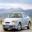

In [31]:
# displaying the sample image
import cv2
from google.colab.patches import cv2_imshow
img = cv2.imread("/content/train/49999.png")
cv2_imshow(img)

In [32]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [33]:
id_list = list(labels_df["id"])

In [34]:
print(id_list[0:5])
print(id_list[-5:])

[1, 2, 3, 4, 5]
[49996, 49997, 49998, 49999, 50000]


Image Processing

In [35]:
# convert images to numpy arrays
train_data_folder = "/content/train/"

data =[]

for id in id_list:
  image = Image.open(train_data_folder + str(id)+ ".png")
  image = np.array(image)
  data.append(image)

In [36]:
type(data)

list

In [37]:
len(data)

50000

In [38]:
type(data[0])

numpy.ndarray

In [39]:
data[0].shape

(32, 32, 3)

In [40]:
# convert images list and labels list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [41]:
type(X)

numpy.ndarray

In [42]:
print(X.shape)
print(Y.shape)

(50000, 32, 32, 3)
(50000,)


Train Test Split

In [43]:
X_train,X_test,Y_train,Y_test  = train_test_split(X,Y,test_size= 0.2,random_state=42,stratify=Y)

In [44]:
print(X_train.shape)
print(X_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)


In [45]:
# scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [46]:
X_train_scaled[0]

array([[[0.21960784, 0.19607843, 0.16470588],
        [0.23137255, 0.2       , 0.16078431],
        [0.2745098 , 0.25490196, 0.2       ],
        ...,
        [0.54117647, 0.60392157, 0.58039216],
        [0.56078431, 0.61960784, 0.6       ],
        [0.61568627, 0.65882353, 0.64705882]],

       [[0.21568627, 0.19607843, 0.14901961],
        [0.24705882, 0.22745098, 0.18431373],
        [0.31764706, 0.30196078, 0.25490196],
        ...,
        [0.52941176, 0.58431373, 0.55686275],
        [0.67058824, 0.73333333, 0.71764706],
        [0.63921569, 0.69411765, 0.69411765]],

       [[0.25098039, 0.24313725, 0.18431373],
        [0.31372549, 0.29803922, 0.2627451 ],
        [0.31764706, 0.30588235, 0.27058824],
        ...,
        [0.64705882, 0.70196078, 0.66666667],
        [0.76078431, 0.82745098, 0.81176471],
        [0.57254902, 0.62352941, 0.63529412]],

       ...,

       [[0.17647059, 0.16078431, 0.13333333],
        [0.19607843, 0.18039216, 0.14509804],
        [0.2627451 , 0

Building the neural Network

In [47]:
import tensorflow as tf
from tensorflow import keras

In [48]:
num_of_classes = 10

# setting up the layers of Neural Network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(num_of_classes,activation="softmax") #if there are more number of output so use softmax otherwise if there are 2 use sigmoid function
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
# compile the neural network
model.compile(optimizer="adam",
              loss = "sparse_categorical_crossentropy",
              metrics =["acc"])

In [50]:
# training the neural network
model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.2555 - loss: 2.0121 - val_acc: 0.2885 - val_loss: 1.9231
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.3033 - loss: 1.8962 - val_acc: 0.3000 - val_loss: 1.8854
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.3141 - loss: 1.8745 - val_acc: 0.2985 - val_loss: 1.9241
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.3223 - loss: 1.8586 - val_acc: 0.3288 - val_loss: 1.8417
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.3252 - loss: 1.8429 - val_acc: 0.2918 - val_loss: 1.9180
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.3282 - loss: 1.8376 - val_acc: 0.3282 - val_loss: 1.8332
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.3324 - loss: 1.8324 - val_acc: 0.3270 - val_loss: 1.8429
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.3330 - loss: 1.8232 - val_acc: 0.3270 - val_loss: 1.8366
Epoch 9/10
1125/1125 ━━━━━━━━━━━━━━━━━━━

ResNet 50

In [51]:
from tensorflow.keras import Sequential,models,layers
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers

In [52]:
convolutional_base = ResNet50(weights="imagenet",include_top=False,input_shape=(256,256,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [53]:
convolutional_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [54]:
num_of_classes = 10

model= models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(convolutional_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128,activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64,activation="relu"))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes,activation="softmax"))

In [55]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),loss="sparse_categorical_crossentropy",metrics=['acc'])

In [56]:
history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 463s 362ms/step - acc: 0.4437 - loss: 1.6751 - val_acc: 0.7730 - val_loss: 0.8644
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 429s 382ms/step - acc: 0.7010 - loss: 1.0154 - val_acc: 0.8885 - val_loss: 0.5010
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 430s 383ms/step - acc: 0.8120 - loss: 0.7376 - val_acc: 0.9193 - val_loss: 0.3622
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 430s 382ms/step - acc: 0.8694 - loss: 0.5734 - val_acc: 0.9295 - val_loss: 0.3022
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 431s 383ms/step - acc: 0.9089 - loss: 0.4508 - val_acc: 0.9315 - val_loss: 0.2608
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 431s 383ms/step - acc: 0.9365 - loss: 0.3527 - val_acc: 0.9398 - val_loss: 0.2287
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 431s 383ms/step - acc: 0.9556 - loss: 0.2812 - val_acc: 0.9370 - val_loss: 0.2344
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 430s 382ms/step - acc: 0.9653 - loss: 0.2335 - val_acc: 0.9415 - val_loss: 0.2141
Epoch 9/

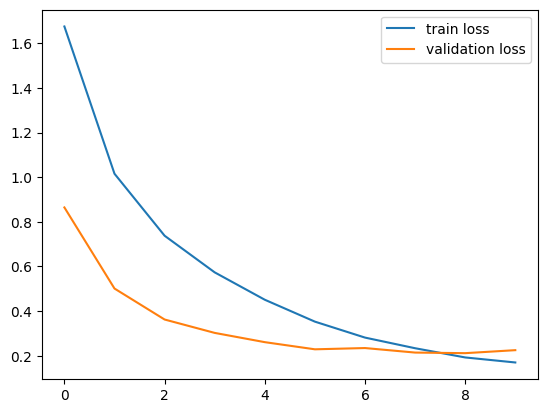

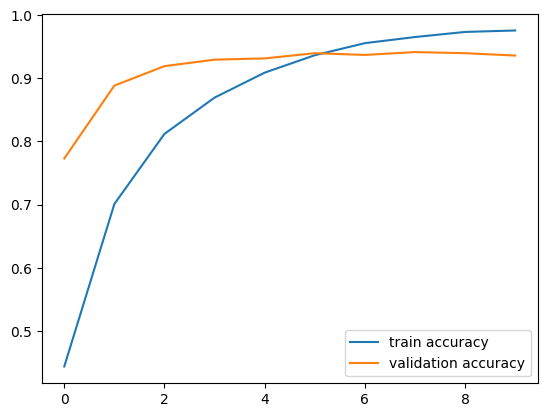

In [57]:
h = history

# plot the loss value
plt.plot(h.history["loss"],label="train loss")
plt.plot(h.history["val_loss"],label="validation loss")
plt.legend()
plt.show()


# plot the accuracy value
plt.plot(h.history['acc'],label="train accuracy")
plt.plot(h.history['val_acc'],label="validation accuracy")
plt.legend()
plt.show()

In [57]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, Y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [59]:
Y_pred = model.predict(X_test_scaled)
Y_pred_labels = np.argmax(Y_pred, axis=1)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(classification_report(Y_test, Y_pred_labels, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step
              precision    recall  f1-score   support

    airplane       0.96      0.93      0.95      1000
  automobile       0.98      0.97      0.97      1000
        bird       0.93      0.93      0.93      1000
         cat       0.86      0.91      0.88      1000
        deer       0.94      0.93      0.94      1000
         dog       0.93      0.88      0.91      1000
        frog       0.94      0.98      0.96      1000
       horse       0.95      0.96      0.96      1000
        ship       0.96      0.97      0.97      1000
       truck       0.96      0.97      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



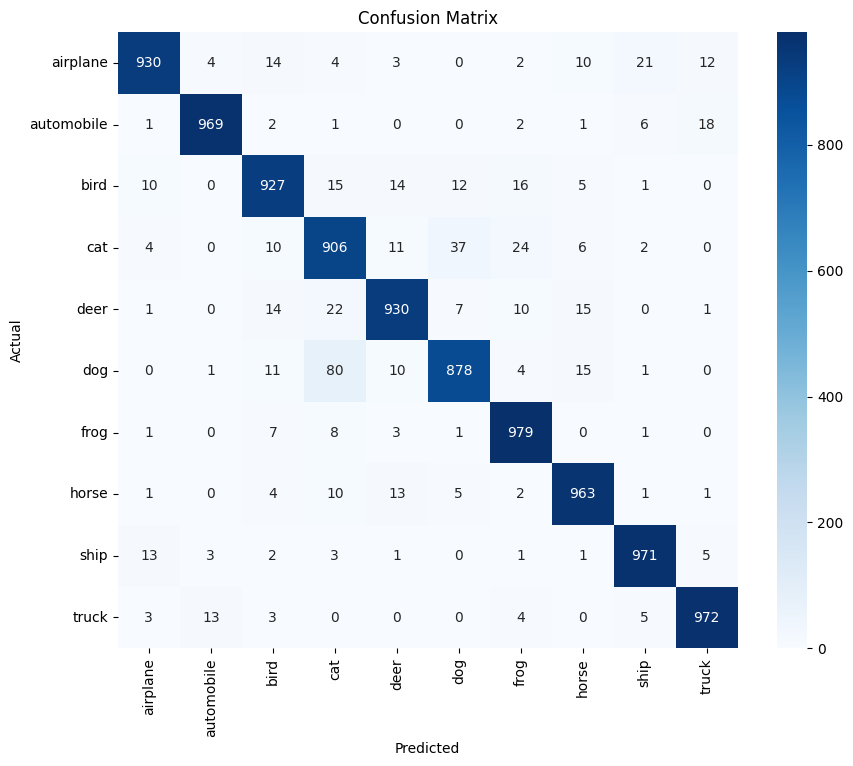

In [60]:
cm = confusion_matrix(Y_test, Y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


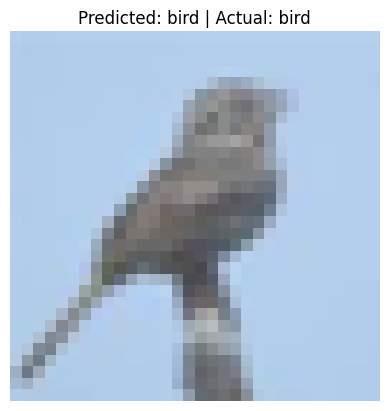

In [61]:
sample_index = 0

sample_image = X_test_scaled[sample_index]
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(prediction)

plt.imshow(X_test[sample_index])
plt.axis("off")
plt.title(f"Predicted: {class_names[predicted_class]} | Actual: {class_names[Y_test[sample_index]]}")
plt.show()

## Conclusion

In this project, CIFAR-10 object recognition was performed using deep learning.

- The CIFAR-10 dataset contains 50,000 training images across 10 classes.
- Images were normalized before model training.
- A baseline neural network was trained for comparison.
- Transfer learning was performed using ResNet50 pretrained on ImageNet.
- The ResNet50-based model achieved strong validation accuracy.
- Final evaluation was performed using test accuracy, classification report, and confusion matrix.
- The trained model was saved for future deployment.

This project demonstrates the use of transfer learning for multi-class image classification.

In [62]:
model.save("cifar10_resnet50_model.keras")
